## Downloading Script - Run Once for Data download

Used Russell 1000 constituent data from iShares proxy. Yfinance used to pull the rest of the price data for the stocks.

In [55]:
import yfinance as yf
import pandas as pd
import time
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. READ & CLEAN THE RUSSELL 1000 UNIVERSE
# ==========================================
print("Step 1: Loading and cleaning index constituents...")

# Read the iShares ETF file (skip the first 9 rows of metadata to hit the headers)
df_iwb = pd.read_csv("IWB_holdings.csv", skiprows=9)

# Extract raw tickers
raw_tickers = df_iwb['Ticker'].dropna().tolist()

# The "Yahoo Finance Translation" map
ticker_map = {
    'BRKB': 'BRK-B', 'BFB': 'BF-B', 'BFA': 'BF-A', 
    'UHALB': 'UHAL-B', 'LENB': 'LEN-B', 'HEIA': 'HEI-A', 'CWENA': 'CWEN-A'
}

cleaned_tickers = []
# Create a dictionary to hold our sector mapping so we can attach it later
sector_map = {}

# Clean the list and build the sector map simultaneously
for index, row in df_iwb.iterrows():
    t = str(row['Ticker']).strip()
    
    # Translate if necessary
    if t in ticker_map:
        t = ticker_map[t]
        
    # Keep valid stocks and map their sectors
    if t not in ['UBFUT', 'ESM6', 'FAM6', 'XTSLA', 'USD', '-', 'nan', '']:
        cleaned_tickers.append(t)
        sector_map[t] = str(row['Sector']).strip()

print(f"--> Extracted {len(cleaned_tickers)} valid tickers.\n")


# ==========================================
# 2. DOWNLOAD HISTORICAL PRICES
# ==========================================
print("Step 2: Downloading historical price data (Dec 2025 - Apr 2026)...")

start_date = "2025-12-31"
end_date = "2026-04-11" # Go one day past the target to ensure the 10th is captured

# Download Russell 1000 Prices
stock_prices = yf.download(cleaned_tickers, start=start_date, end=end_date)['Close']
stock_prices.to_csv("russell_1000_prices_clean.csv")

# Download S&P 500 Prices
sp500_prices = yf.download("^GSPC", start=start_date, end=end_date)['Close']
sp500_prices.to_csv("sp500_prices_clean.csv")

print("--> Price data saved successfully.\n")


# ==========================================
# 3. FETCH MARKET CAPS & BUILD METADATA FILE
# ==========================================
print("Step 3: Fetching Market Capitalization data. This will take a few minutes...")

metadata = []

# Loop through our cleaned list to pull individual market caps
for i, ticker in enumerate(cleaned_tickers):
    try:
        # Fetch the metadata
        info = yf.Ticker(ticker).info
        market_cap = info.get('marketCap', 0)
        
        # Append the ticker, its sector from the IWB file, and the live market cap
        metadata.append({
            'Ticker': ticker,
            'Sector': sector_map.get(ticker, 'Unknown'),
            'Market Cap': market_cap
        })
        
        # Print progress every 100 tickers so you know it hasn't frozen
        if (i + 1) % 100 == 0:
            print(f"    Fetched {i + 1} / {len(cleaned_tickers)}...")
            
    except Exception as e:
        # If Yahoo Finance fails for a specific ticker, we record it with a 0 cap
        metadata.append({
            'Ticker': ticker,
            'Sector': sector_map.get(ticker, 'Unknown'),
            'Market Cap': 0
        })
        continue

# Save the metadata to a CSV
df_metadata = pd.DataFrame(metadata)
df_metadata.to_csv("russell_1000_metadata.csv", index=False)

print("--> Metadata (Sectors & Market Caps) saved successfully.")
print("\n--- DATA PIPELINE COMPLETE ---")

[                       0%                       ]  4 of 1003 completed

Step 1: Loading and cleaning index constituents...
--> Extracted 1003 valid tickers.

Step 2: Downloading historical price data (Dec 2025 - Apr 2026)...


[*********************100%***********************]  1003 of 1003 completed
[*********************100%***********************]  1 of 1 completed


--> Price data saved successfully.

Step 3: Fetching Market Capitalization data. This will take a few minutes...
    Fetched 100 / 1003...
    Fetched 200 / 1003...
    Fetched 300 / 1003...
    Fetched 400 / 1003...
    Fetched 500 / 1003...
    Fetched 600 / 1003...
    Fetched 700 / 1003...
    Fetched 800 / 1003...
    Fetched 900 / 1003...
--> Metadata (Sectors & Market Caps) saved successfully.

--- DATA PIPELINE COMPLETE ---


## Load the datasets and apply a >$30B Market Cap Filter to get the Large Caps
Calculate the performance for the stocks across the two periods/phases:
1. Pre-war - 31st December 2025 to 27th February 2026
2. Post-war - 27th February to 10th April 2026

In [98]:
# 1. Load the clean offline datasets
sp500 = pd.read_csv("sp500_prices_clean.csv", index_col="Date", parse_dates=True)['^GSPC']
df_stocks = pd.read_csv("russell_1000_prices_clean.csv", index_col="Date", parse_dates=True)
df_meta = pd.read_csv("russell_1000_metadata.csv")

# 2. Apply the Strict >$30B Market Cap Filter FIRST
df_large_cap = df_meta[df_meta['Market Cap'] > 30_000_000_000].copy()
eligible_tickers = df_large_cap['Ticker'].tolist()

# Isolate the price data for only these eligible large-cap stocks
valid_tickers = [t for t in eligible_tickers if t in df_stocks.columns]
df_stocks_filtered = df_stocks[valid_tickers]

# 3. Calculate S&P 500 Benchmark Returns
p1_start, p1_end = '2025-12-31', '2026-02-27'
p2_start, p2_end = '2026-02-27', '2026-04-10'

sp500_p1 = (sp500.loc[p1_end] / sp500.loc[p1_start]) - 1
sp500_p2 = (sp500.loc[p2_end] / sp500.loc[p2_start]) - 1

# 4. Iterate and Calculate Stock Performance
results_list = []
for ticker in valid_tickers:
    try:
        prices = df_stocks_filtered[ticker]
        stock_p1 = (prices.loc[p1_end] / prices.loc[p1_start]) - 1
        stock_p2 = (prices.loc[p2_end] / prices.loc[p2_start]) - 1
        
        results_list.append({
            'Ticker': ticker,
            'Sector': df_large_cap.loc[df_large_cap['Ticker'] == ticker, 'Sector'].values[0],
            'Market Cap': df_large_cap.loc[df_large_cap['Ticker'] == ticker, 'Market Cap'].values[0],
            'Phase 1 Return': stock_p1,
            'Phase 2 Return': stock_p2,
            'Outperformed P1': stock_p1 > sp500_p1,
            'Outperformed P2': stock_p2 > sp500_p2
        })
    except KeyError:
        continue

df_results = pd.DataFrame(results_list)

# 5. Extract the specific funnel counts
p1_winners = df_results[df_results['Outperformed P1']]
p2_winners = df_results[df_results['Outperformed P2']]
consistent_winners = df_results[df_results['Outperformed P1'] & df_results['Outperformed P2']]

print(f"Eligible Large-Cap Universe (>$30B): {len(df_results)} stocks")
print(f"Phase 1 Outperformers: {len(p1_winners)}")
print(f"Phase 2 Outperformers: {len(p2_winners)}")
print(f"Consistent Outperformers (Both Phases): {len(consistent_winners)}")

Eligible Large-Cap Universe (>$30B): 334 stocks
Phase 1 Outperformers: 216
Phase 2 Outperformers: 130
Consistent Outperformers (Both Phases): 95


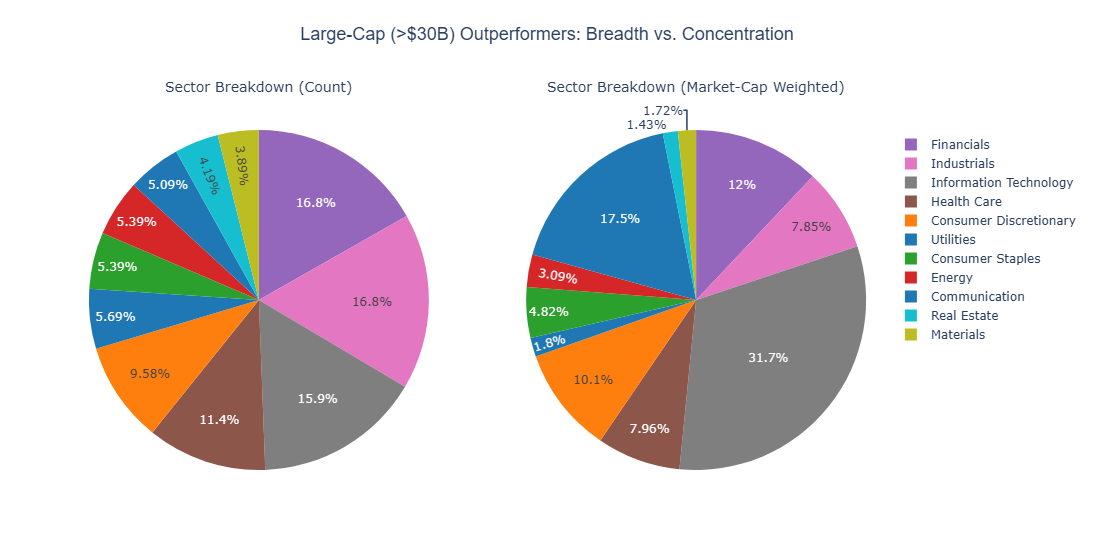

In [109]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Calculate aggregates
sector_counts = df_results['Sector'].value_counts().reset_index()
sector_counts.columns = ['Sector', 'Count']

# Sort by Count (Descending) to establish the master order
sector_counts = sector_counts.sort_values(by='Count', ascending=False)
ordered_sectors = sector_counts['Sector'].tolist()

# 2. Calculate Market Cap Weights and force it into the exact same order
sector_weights = df_results.groupby('Sector')['Market Cap'].sum().reset_index()
sector_weights.columns = ['Sector', 'Total Market Cap']
# Reindex to match the Count order
sector_weights = sector_weights.set_index('Sector').reindex(ordered_sectors).reset_index()

# 3. Apply the consistent master palette based on the ordered list
colors_mapped = [master_palette.get(sec, '#333333') for sec in ordered_sectors]

# Create side-by-side pie charts
fig = make_subplots(rows=1, cols=2, specs=[[{'type': 'domain'}, {'type': 'domain'}]],
                    subplot_titles=['Sector Breakdown (Count)', 'Sector Breakdown (Market-Cap Weighted)'])

# Pie 1: Count (Sorted largest to smallest)
fig.add_trace(go.Pie(labels=sector_counts['Sector'], values=sector_counts['Count'], 
                     marker=dict(colors=colors_mapped), name='Count',
                     sort=False, # Disable Plotly's auto-sort so it uses our dataframe order
                     direction='clockwise', # Start at 12 o'clock and go clockwise
                     hovertemplate="<b>%{label}</b><br>Count: %{value}<br>Share: %{percent}<extra></extra>"),
              1, 1)

# Pie 2: Market Cap Weighted (Forced into the same slice order as Pie 1)
fig.add_trace(go.Pie(labels=sector_weights['Sector'], values=sector_weights['Total Market Cap'], 
                     marker=dict(colors=colors_mapped), name='Notional',
                     sort=False, # Must be False to maintain the parallel order
                     direction='clockwise',
                     hovertemplate="<b>%{label}</b><br>Market Cap: $%{value:,.0f}<br>Share: %{percent}<extra></extra>"),
              1, 2)

fig.update_layout(
    title={
        'text': "Large-Cap (>$30B) Outperformers: Breadth vs. Concentration",
        'y': 0.95,               # Vertical position (0 to 1)
        'x': 0.5,                # Horizontal center
        'xanchor': 'center',     # Anchor the text at the center
        'yanchor': 'top',
        'font': dict(size=18, family="Arial, bold")
    },
    margin=dict(t=130),          # Increase top margin to give titles room to breathe
    height=550                   # Slightly taller to accommodate the gaps
)

# Move subplot titles (Subtitles) slightly higher
# This loop looks for the annotations created by 'subplot_titles'
for annotation in fig.layout.annotations:
    annotation.y += 0.10         # Increase this value to move subtitles further up
    annotation.font.size = 14    # Optional: adjust subtitle font size if needed

fig.show()

## Aggregating the Sectorial Performance

We aggregate the Sectorial Performance, looking at median, mean and max just to see the 

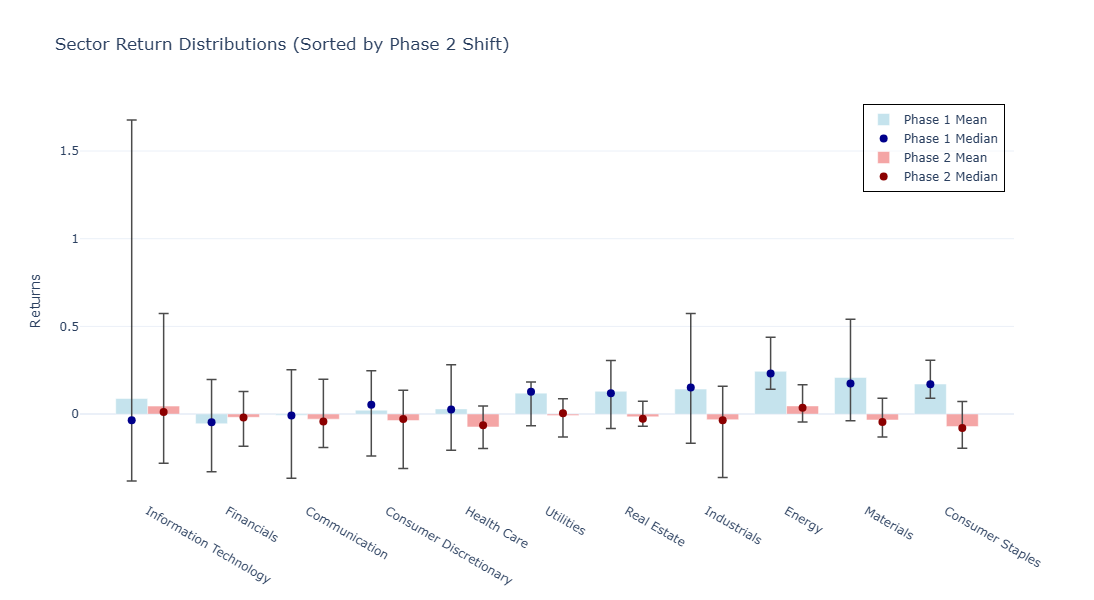

In [126]:
import plotly.graph_objects as go
import numpy as np

# Assuming agg_metrics is calculated and sorted as before
sectors = agg_metrics.index
x_base = np.arange(len(sectors)) # Create numeric base for exact placement
offset = 0.2 # The exact manual shift for Phase 1 (left) and Phase 2 (right)

fig = go.Figure()

# --- PHASE 1 TRACES (Shifted Left) ---
fig.add_trace(go.Bar(
    name='Phase 1 Mean', x=x_base - offset, y=agg_metrics['Phase 1 Return_mean'],
    marker_color='lightblue', opacity=0.7, width=0.4, textposition='none',
    error_y=dict(
        type='data', symmetric=False,
        array=agg_metrics['Phase 1 Return_max'] - agg_metrics['Phase 1 Return_mean'],
        arrayminus=agg_metrics['Phase 1 Return_mean'] - agg_metrics['Phase 1 Return_min'],
        color='black', thickness=1.5, width=5
    ),
    customdata=agg_metrics[['Phase 1 Return_median', 'Phase 1 Return_min', 'Phase 1 Return_max', 'Median_Delta']],
    hovertemplate="<b>%{text} (Phase 1)</b><br>Mean: %{y:.2%}<br>Median: %{customdata[0]:.2%}<br>Min: %{customdata[1]:.2%}<br>Max: %{customdata[2]:.2%}<br>Shift into Phase 2: %{customdata[3]:.2%}<extra></extra>",
    text=sectors # Pass the text names for the hover tooltip
))

# Explicitly place Median Dots on the exact same shifted X-axis
fig.add_trace(go.Scatter(
    name='Phase 1 Median', x=x_base - offset, y=agg_metrics['Phase 1 Return_median'],
    mode='markers', marker=dict(color='darkblue', size=8),
    hoverinfo='skip' # Prevent double hover tooltips
))

# --- PHASE 2 TRACES (Shifted Right) ---
fig.add_trace(go.Bar(
    name='Phase 2 Mean', x=x_base + offset, y=agg_metrics['Phase 2 Return_mean'],
    marker_color='lightcoral', opacity=0.7, width=0.4, textposition='none',
    error_y=dict(
        type='data', symmetric=False,
        array=agg_metrics['Phase 2 Return_max'] - agg_metrics['Phase 2 Return_mean'],
        arrayminus=agg_metrics['Phase 2 Return_mean'] - agg_metrics['Phase 2 Return_min'],
        color='black', thickness=1.5, width=5
    ),
    customdata=agg_metrics[['Phase 2 Return_median', 'Phase 2 Return_min', 'Phase 2 Return_max', 'Median_Delta']],
    hovertemplate="<b>%{text} (Phase 2)</b><br>Mean: %{y:.2%}<br>Median: %{customdata[0]:.2%}<br>Min: %{customdata[1]:.2%}<br>Max: %{customdata[2]:.2%}<extra></extra>",
    text=sectors
))

fig.add_trace(go.Scatter(
    name='Phase 2 Median', x=x_base + offset, y=agg_metrics['Phase 2 Return_median'],
    mode='markers', marker=dict(color='darkred', size=8),
    hoverinfo='skip'
))

# Overwrite the numeric X-axis with the actual Sector names
fig.update_layout(
    title='Sector Return Distributions (Sorted by Phase 2 Shift)',
    yaxis_title='Returns',
    xaxis=dict(tickmode='array', tickvals=x_base, ticktext=sectors),
    barmode='overlay', # Change to overlay since we manually offset the bars
    height=600, 
    width=1090, # Increased width to create more space between sectors
    template='plotly_white',
    hovermode='x unified',

    legend=dict(
        yanchor="top",
        y=0.99,           # 1.0 is the very top
        xanchor="right",
        x=0.99,           # 1.0 is the very far right
        bgcolor="rgba(255, 255, 255, 0.5)", # Semi-transparent white
        bordercolor="Black",
        borderwidth=1
    )
)
fig.show()

## Plotting Sectorial Data for each Period

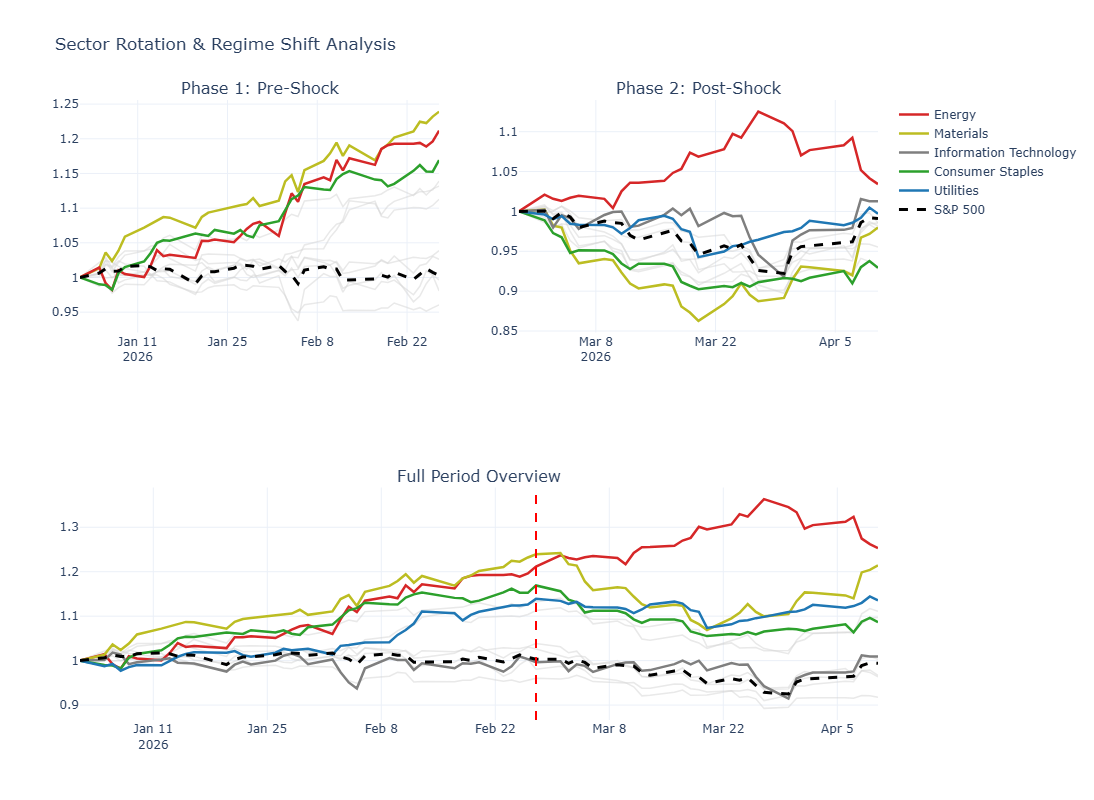

In [119]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import pandas as pd

fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "xy"}, {"type": "xy"}],
           [{"type": "xy", "colspan": 2}, None]],
    subplot_titles=("Phase 1: Pre-Shock", "Phase 2: Post-Shock", "Full Period Overview")
)

def add_subplot_traces(fig, start_date, end_date, highlight_sectors, row, col, add_vline=False):
    s_returns = sector_daily.loc[start_date:end_date]
    sp_returns = sp500_returns.loc[start_date:end_date]
    
    s_indexed = (1 + s_returns).cumprod() / (1 + s_returns).cumprod().iloc[0]
    sp_indexed = (1 + sp_returns).cumprod() / (1 + sp_returns).cumprod().iloc[0]
    
    # Plot background (grey) sectors
    for sector in s_indexed.columns:
        if sector not in highlight_sectors:
            fig.add_trace(go.Scatter(x=s_indexed.index, y=s_indexed[sector], mode='lines', 
                                     line=dict(color='lightgrey', width=1.5), opacity=0.5, 
                                     name=sector, showlegend=False, 
                                     hovertemplate="<b>%{fullData.name}</b>: %{y:.3f}<extra></extra>"), 
                                     row=row, col=col)
            
    # Plot highlighted sectors
    for sector in highlight_sectors:
        fig.add_trace(go.Scatter(x=s_indexed.index, y=s_indexed[sector], mode='lines', 
                                     line=dict(color=master_palette.get(sector, 'black'), width=2.5), 
                                     name=sector, showlegend=(row==2),
                                     hovertemplate="<b>%{fullData.name}</b>: %{y:.3f}<extra></extra>"), 
                                     row=row, col=col) 

    # Plot S&P 500
    fig.add_trace(go.Scatter(x=sp_indexed.index, y=sp_indexed, mode='lines', 
                                 line=dict(color='black', width=3, dash='dash'), 
                                 name='S&P 500', showlegend=(row==2),
                                 hovertemplate="<b>%{fullData.name}</b>: %{y:.3f}<extra></extra>"), 
                                 row=row, col=col)
                                 
    if add_vline:
        fig.add_vline(x=pd.to_datetime('2026-02-27'), line_width=2, line_dash="dash", line_color="red", row=row, col=col)

# Render traces
add_subplot_traces(fig, '2025-12-31', '2026-02-27', top3_p1, 1, 1)
add_subplot_traces(fig, '2026-02-27', '2026-04-10', combined_highlights, 1, 2)
add_subplot_traces(fig, '2025-12-31', '2026-04-10', combined_highlights, 2, 1, add_vline=True)

fig.update_layout(height=800, template='plotly_white', title_text="Sector Rotation & Regime Shift Analysis", hovermode='x unified')
fig.show()

In [88]:
def calculate_effective_levers(returns_df):
    # Calculate the variance contribution of each sector
    variances = returns_df.var()
    total_variance = variances.sum()
    
    # Transform into probability-like weights (must sum to 1)
    weights = variances / total_variance
    
    # Calculate Shannon Entropy: H = -sum(p * ln(p))
    # Add a tiny epsilon to avoid log(0)
    entropy = -np.sum(weights * np.log(weights + 1e-10))
    
    # Second term: Number of effective levers
    n_effective = np.exp(entropy)
    return entropy, n_effective

# Slice daily returns for both phases
p1_sector_returns = sector_daily.loc['2025-12-31':'2026-02-27']
p2_sector_returns = sector_daily.loc['2026-02-27':'2026-04-10']

h_p1, n_p1 = calculate_effective_levers(p1_sector_returns)
h_p2, n_p2 = calculate_effective_levers(p2_sector_returns)

print(f"Phase 1 - Shannon Entropy: {h_p1:.3f} | Effective Levers: {n_p1:.2f}")
print(f"Phase 2 - Shannon Entropy: {h_p2:.3f} | Effective Levers: {n_p2:.2f}")
print(f"Change in Effective Diversification: {n_p2 - n_p1:.2f} levers")

Phase 1 - Shannon Entropy: 2.284 | Effective Levers: 9.82
Phase 2 - Shannon Entropy: 2.290 | Effective Levers: 9.88
Change in Effective Diversification: 0.06 levers


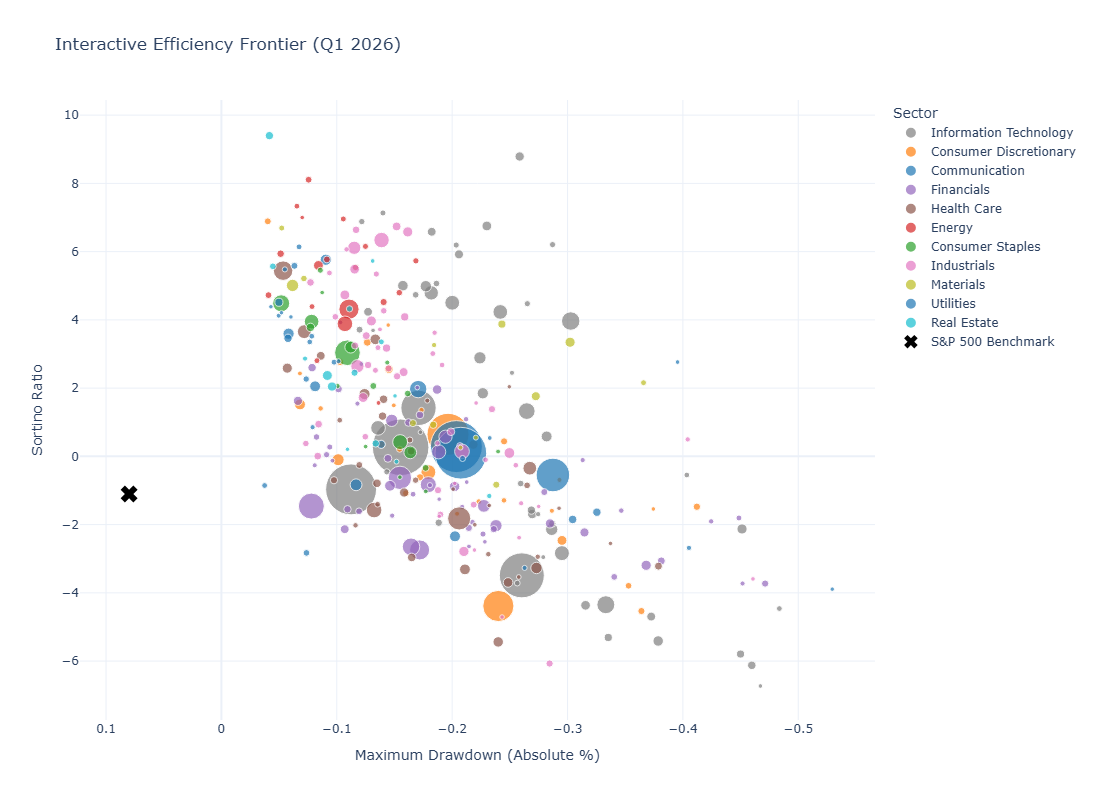

In [91]:
import pandas as pd
import numpy as np
import plotly.express as px

# 1. Create a dictionary to map Tickers to Full Company Names
# Assuming df_iwb is your original loaded IWB_holdings.csv
name_map = dict(zip(df_iwb['Ticker'], df_iwb['Name']))

risk_free_rate = 0.045 / 252 
metrics_list = []

for ticker in valid_tickers: 
    prices = df_stocks_filtered[ticker]
    daily_ret = prices.pct_change().dropna()
    
    # Sharpe
    excess = daily_ret - risk_free_rate
    sharpe = np.sqrt(252) * (excess.mean() / excess.std())
    
    # Sortino
    downside_std = (daily_ret[daily_ret < 0]).std() * np.sqrt(252)
    sortino = ((daily_ret.mean() * 252) - 0.045) / downside_std if downside_std != 0 else np.nan
    
    # Max Drawdown
    cum_ret = (1 + daily_ret).cumprod()
    max_dd = ((cum_ret - cum_ret.cummax()) / cum_ret.cummax()).min()
    
    # Extract Metadata
    market_cap = df_large_cap.loc[df_large_cap['Ticker'] == ticker, 'Market Cap'].values[0]
    sector = df_large_cap.loc[df_large_cap['Ticker'] == ticker, 'Sector'].values[0] 
    
    # Get the full company name (default to the ticker if not found)
    company_name = name_map.get(ticker, ticker)
    
    metrics_list.append({
        'Ticker': ticker,
        'Company Name': company_name, # Added Company Name
        'Sector': sector,
        'Sharpe': sharpe,
        'Sortino Ratio': sortino,
        'Max Drawdown': max_dd,
        'Market Cap': market_cap
    })

df_metrics = pd.DataFrame(metrics_list).dropna()

# 2. Map the consistent colors (Ensure master_palette exists)
color_discrete_map = {sec: master_palette[sec] for sec in df_metrics['Sector'].unique()}

# 3. Generate the Interactive Plotly Chart
fig = px.scatter(
    df_metrics,
    x="Max Drawdown",
    y="Sortino Ratio",
    size="Market Cap",
    color="Sector", 
    color_discrete_map=color_discrete_map, 
    hover_name="Company Name", # Set hover title to the full name
    hover_data={"Ticker": True, "Sharpe": True, "Market Cap": True, "Max Drawdown": True}, # Customize hover details
    title="Interactive Efficiency Frontier (Q1 2026)",
    labels={"Max Drawdown": "Maximum Drawdown (Absolute %)", "Sortino Ratio": "Sortino Ratio"},
    size_max=40,
    template="plotly_white",
    height=800, 
    width=1090  
)

# Reverse the X-axis
fig.update_xaxes(autorange="reversed")

# Add the S&P 500 Baseline 
fig.add_scatter(
    x=[abs(sp500_max_dd)], 
    y=[sp500_sortino], 
    mode='markers', 
    marker=dict(size=15, color='black', symbol='x'), 
    name='S&P 500 Benchmark'
)

fig.show()

In [61]:
# Aggregate median returns for each phase
sector_phase_returns = df_results.groupby('Sector')[['Phase 1 Return', 'Phase 2 Return']].median()

# Calculate the Delta (Shift in momentum)
sector_phase_returns['Regime Shift Delta'] = sector_phase_returns['Phase 2 Return'] - sector_phase_returns['Phase 1 Return']

# Sort by the biggest positive shift (Sectors that gained momentum or recovered best in Phase 2)
sector_delta_sorted = sector_phase_returns.sort_values(by='Regime Shift Delta', ascending=False)

print("--- SECTOR MOMENTUM SHIFT (Phase 1 to Phase 2) ---")
display(sector_delta_sorted.style.format({
    'Phase 1 Return': '{:.2%}',
    'Phase 2 Return': '{:.2%}',
    'Regime Shift Delta': '{:.2%}'
}).background_gradient(subset=['Regime Shift Delta'], cmap='RdYlGn'))

--- SECTOR MOMENTUM SHIFT (Phase 1 to Phase 2) ---


,Phase 1 Return,Phase 2 Return,Regime Shift Delta
Sector,,,
Information Technology,-3.58%,1.24%,4.81%
Financials,-4.66%,-1.90%,2.76%
Communication,-0.76%,-4.17%,-3.41%
Consumer Discretionary,5.32%,-2.87%,-8.19%
Health Care,2.59%,-6.37%,-8.96%
Utilities,12.73%,0.50%,-12.24%
Real Estate,11.83%,-2.69%,-14.52%
Industrials,15.09%,-3.58%,-18.67%
Energy,23.11%,3.67%,-19.44%


In [62]:
# Calculate individual ticker delta
df_results['Regime Shift Delta'] = df_results['Phase 2 Return'] - df_results['Phase 1 Return']

# Top 5 "Shock Absorbers" (Biggest positive shift into Phase 2)
shock_absorbers = df_results.sort_values(by='Regime Shift Delta', ascending=False).head(5)

# Top 5 "Value Traps" (Biggest negative shift moving into Phase 2, despite surviving)
value_traps = df_results.sort_values(by='Regime Shift Delta', ascending=True).head(5)

print("--- TOP 5 SHOCK ABSORBERS (Gained strength in the crisis) ---")
display(shock_absorbers[['Ticker', 'Sector', 'Phase 1 Return', 'Phase 2 Return', 'Regime Shift Delta']].style.format({
    'Phase 1 Return': '{:.2%}',
    'Phase 2 Return': '{:.2%}',
    'Regime Shift Delta': '{:.2%}'
}))

print("\n--- TOP 5 VALUE TRAPS (Lost the most momentum in the crisis) ---")
display(value_traps[['Ticker', 'Sector', 'Phase 1 Return', 'Phase 2 Return', 'Regime Shift Delta']].style.format({
    'Phase 1 Return': '{:.2%}',
    'Phase 2 Return': '{:.2%}',
    'Regime Shift Delta': '{:.2%}'
}))

--- TOP 5 SHOCK ABSORBERS (Gained strength in the crisis) ---


,Ticker,Sector,Phase 1 Return,Phase 2 Return,Regime Shift Delta
99,MRVL,Information Technology,-3.80%,57.37%,61.17%
170,KKR,Financials,-31.10%,4.04%,35.13%
324,RDDT,Communication,-36.57%,-4.17%,32.40%
314,EXPE,Consumer Discretionary,-23.87%,5.98%,29.85%
20,AMD,Information Technology,-6.51%,22.39%,28.91%



--- TOP 5 VALUE TRAPS (Lost the most momentum in the crisis) ---


,Ticker,Sector,Phase 1 Return,Phase 2 Return,Regime Shift Delta
80,SNDK,Information Technology,167.66%,34.06%,-133.59%
328,SCCO,Materials,54.11%,-11.79%,-65.91%
198,AU,Materials,49.82%,-13.06%,-62.88%
183,LITE,Information Technology,90.16%,28.02%,-62.14%
79,GLW,Information Technology,72.07%,13.87%,-58.19%


C:\ProgramData\anaconda3\envs\fin-env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


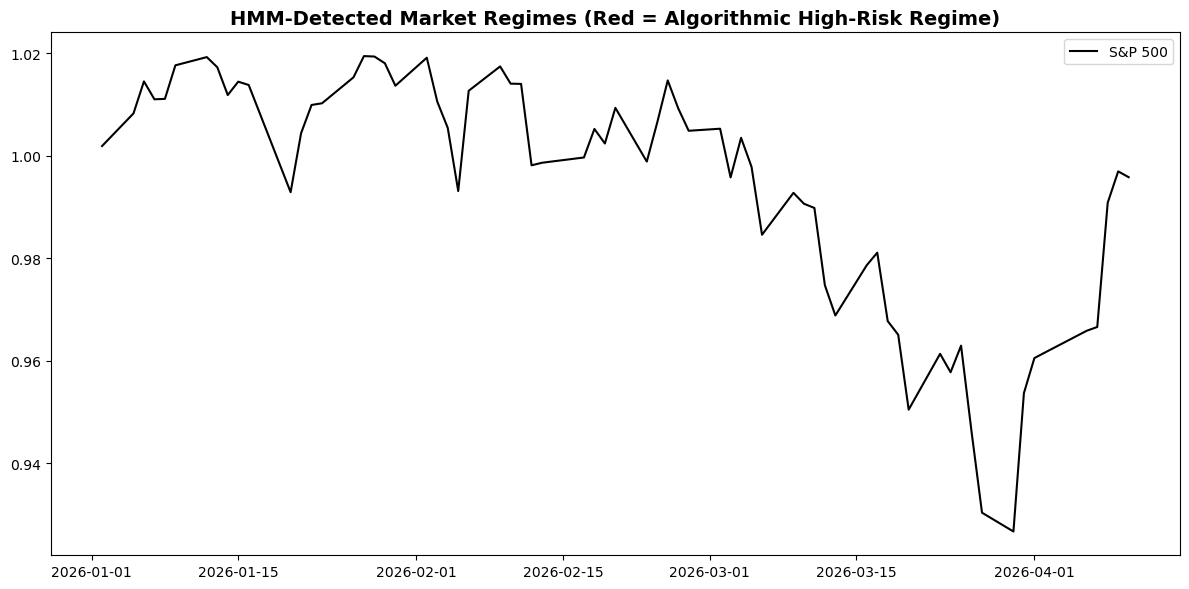

In [67]:
from hmmlearn import hmm
import numpy as np

# Use the S&P 500 daily returns to identify broad market regimes
sp500_ret = sp500.pct_change().dropna()

# HMMs need a 2D array, and we use absolute returns (volatility proxy) alongside raw returns
X = np.column_stack([sp500_ret.values, np.abs(sp500_ret.values)])

# Initialize a 2-Regime Hidden Markov Model
# We assume 2 regimes: Normal Market vs. Crisis Market
model = hmm.GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=42)
model.fit(X)

# Predict the hidden states (Regime 0 or Regime 1 for every single day)
hidden_states = model.predict(X)

# Create a clean dataframe to view the regimes over time
regime_df = pd.DataFrame({
    'S&P 500 Return': sp500_ret,
    'Regime': hidden_states
}, index=sp500_ret.index)

# Plot the S&P 500, coloring the background based on the algorithmic regime
plt.figure(figsize=(12, 6))
plt.plot(sp500_ret.index, (1 + sp500_ret).cumprod(), color='black', label='S&P 500 Indexed')

# Shade the background based on the HMM prediction
for i in range(len(regime_df) - 1):
    if regime_df['Regime'].iloc[i] == 1:
        plt.axvspan(regime_df.index[i], regime_df.index[i+1], color='red', alpha=0.2, lw=0)

plt.title('HMM-Detected Market Regimes (Red = Algorithmic High-Risk Regime)', fontsize=14, fontweight='bold')
plt.legend(['S&P 500', 'High Volatility Regime'])
plt.tight_layout()
plt.show()

In [81]:
from sklearn.decomposition import PCA
import numpy as np

def calculate_pca_variance(returns_df):
    # Standardize the data (mean=0, variance=1) before running PCA
    returns_standardized = (returns_df - returns_df.mean()) / returns_df.std()
    
    pca = PCA()
    pca.fit(returns_standardized.fillna(0)) # Fill NaNs to allow PCA to run
    
    # Extract the percentage of variance explained by PC1 (The "Market" Factor)
    pc1_variance = pca.explained_variance_ratio_[0]
    return pc1_variance

# Run PCA on the individual stock returns (not the sector averages) for both phases
pc1_p1 = calculate_pca_variance(df_stocks_filtered.loc['2025-12-31':'2026-02-27'])
pc1_p2 = calculate_pca_variance(df_stocks_filtered.loc['2026-02-27':'2026-04-10'])

print("--- PCA: EXPLANATORY POWER OF THE MARKET FACTOR (PC1) ---")
print(f"Phase 1 (Pre-Shock): PC1 explains {pc1_p1:.2%} of total stock variance.")
print(f"Phase 2 (Post-Shock): PC1 explains {pc1_p2:.2%} of total stock variance.")

--- PCA: EXPLANATORY POWER OF THE MARKET FACTOR (PC1) ---
Phase 1 (Pre-Shock): PC1 explains 62.20% of total stock variance.
Phase 2 (Post-Shock): PC1 explains 46.16% of total stock variance.


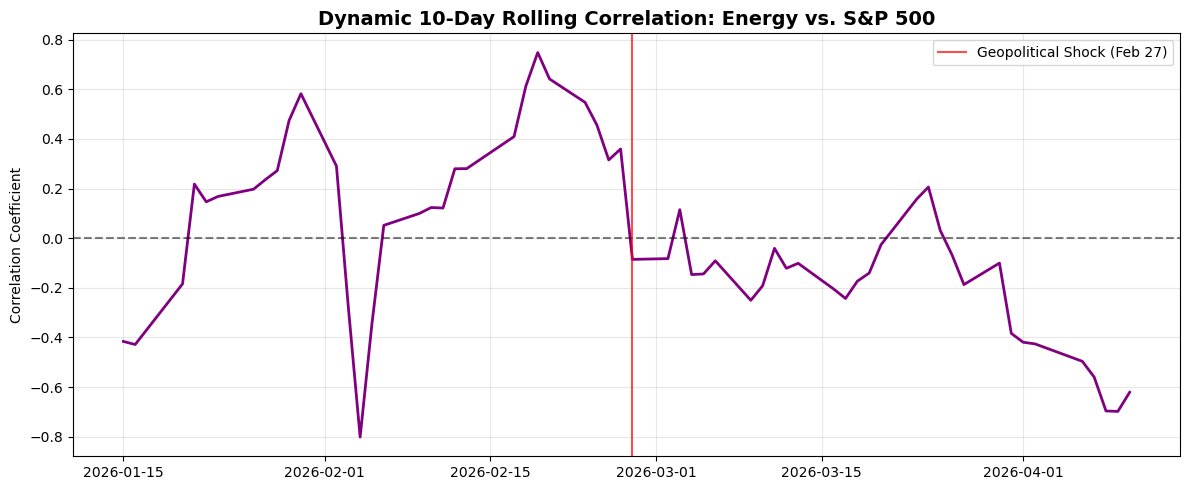

In [82]:
# Calculate a 10-day rolling correlation between the Energy sector and the S&P 500
rolling_window = 10

# Align the series
energy_returns = sector_daily['Energy'] # Assuming 'Energy' is a valid column
benchmark_returns = sp500_returns

# Calculate rolling correlation
dynamic_corr = energy_returns.rolling(window=rolling_window).corr(benchmark_returns)

plt.figure(figsize=(12, 5))
plt.plot(dynamic_corr.index, dynamic_corr, color='purple', linewidth=2)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)

# Highlight the February 27th Regime Shift
plt.axvline(pd.to_datetime('2026-02-27'), color='red', linestyle='-', alpha=0.7, label='Geopolitical Shock (Feb 27)')

plt.title('Dynamic 10-Day Rolling Correlation: Energy vs. S&P 500', fontsize=14, fontweight='bold')
plt.ylabel('Correlation Coefficient')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [83]:
import yfinance as yf
from statsmodels.tsa.stattools import coint

# 1. Download 2 years of history for a classic pair
print("Downloading 2-year history for Stat Arb Cointegration test...")
pair_data = yf.download(['CVX', 'XOM'], start="2024-01-01", end="2026-04-10")['Close']

# Split into historical training data and our 2026 "Shock" data
history_cvx = pair_data['CVX'].loc['2024-01-01':'2025-12-31'].dropna()
history_xom = pair_data['XOM'].loc['2024-01-01':'2025-12-31'].dropna()

shock_cvx = pair_data['CVX'].loc['2026-01-01':'2026-04-10'].dropna()
shock_xom = pair_data['XOM'].loc['2026-01-01':'2026-04-10'].dropna()

# 2. Run the Engle-Granger Cointegration Test
# The null hypothesis is NO cointegration. A p-value < 0.05 rejects the null.
score, p_value_hist, _ = coint(history_cvx, history_xom)
score, p_value_shock, _ = coint(shock_cvx, shock_xom)

print("\n--- COINTEGRATION (STATISTICAL ARBITRAGE) TEST ---")
print("Pair Tested: CVX (Chevron) vs XOM (ExxonMobil)")
print(f"Historical P-Value (2024-2025): {p_value_hist:.4f}")

if p_value_hist < 0.05:
    print("-> Result: The pair WAS historically cointegrated. A valid Stat Arb pair.")
else:
    print("-> Result: The pair was NOT historically cointegrated.")

print(f"\nQ1 2026 Shock P-Value: {p_value_shock:.4f}")

if p_value_shock < 0.05:
    print("-> Result: The pair REMAINS cointegrated. The structural relationship survived the shock.")
else:
    print("-> Result: The pair BROKE cointegration. The Q1 volatility shattered the equilibrium.")

[*********************100%***********************]  2 of 2 completed


--- COINTEGRATION (STATISTICAL ARBITRAGE) TEST ---
Pair Tested: CVX (Chevron) vs XOM (ExxonMobil)
Historical P-Value (2024-2025): 0.1621
-> Result: The pair was NOT historically cointegrated.

Q1 2026 Shock P-Value: 0.3608
-> Result: The pair BROKE cointegration. The Q1 volatility shattered the equilibrium.
